# GeoAtt-PointNet++ — Phase 2: Compare & Analyze

Post-hoc analysis dari hasil 4-variant fair ablation. **CPU only** — jalankan di Colab setelah notebook 01 selesai (atau lokal jika `EVAL_DIR` ter-sync dari Drive).

**Tujuan utama:** menguji hipotesis bahwa **GeoAtt memberikan dampak signifikan** terhadap identifikasi telapak tangan, lewat paired t-test `with_geom` vs `no_geom` per seed.

## 1. Setup

In [1]:
from google.colab import drive
drive.mount("/content/drive")

import sys
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

PROJECT_ROOT = Path("/content/drive/MyDrive/3DCNN")
EVAL_DIR   = PROJECT_ROOT / "eval_results"
OUTPUT_DIR = PROJECT_ROOT / "analysis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils.compare_utils import (
    load_all_results,
    aggregate_by_variant,
    format_mean_std,
    paired_ttest,
    export_latex_table,
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

VARIANTS = ["no_geom", "gam_only", "fuse_only", "with_geom"]
SEEDS    = [7, 42, 123, 2026, 31337]

print(f"EVAL_DIR:   {EVAL_DIR}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")


Mounted at /content/drive
EVAL_DIR:   /content/drive/MyDrive/3DCNN/eval_results
OUTPUT_DIR: /content/drive/MyDrive/3DCNN/analysis


## 2. Load Results

In [2]:
df_test    = load_all_results(EVAL_DIR, holdout=False)
df_holdout = load_all_results(EVAL_DIR, holdout=True)

print("Test results per variant:")
print(df_test.groupby("variant").size())
print()
print("Holdout results per variant:")
print(df_holdout.groupby("variant").size())


Test results per variant:
variant
fuse_only    5
gam_only     5
no_geom      5
with_geom    5
dtype: int64

Holdout results per variant:
variant
fuse_only    5
gam_only     5
no_geom      5
with_geom    5
dtype: int64


## 3. Aggregation Table (Mean ± Std)

In [3]:
all_metrics = ["eer", "auc", "tar_at_far1", "tar_at_far01", "dprime", "rank1", "rank5", "rank10"]
metrics = [m for m in all_metrics if m in df_test.columns]

print("=== TEST SET ===")
for m in metrics:
    print(f"\n{m.upper()}:")
    print(format_mean_std(df_test, m))

print("\n=== HOLDOUT SET ===")
for m in metrics:
    print(f"\n{m.upper()}:")
    print(format_mean_std(df_holdout, m))


=== TEST SET ===

EER:
variant
fuse_only    0.1392 ± 0.0183
gam_only     0.2698 ± 0.0362
no_geom      0.0017 ± 0.0026
with_geom    0.2016 ± 0.0243
Name: eer, dtype: object

AUC:
variant
fuse_only    0.9066 ± 0.0122
gam_only     0.7993 ± 0.0409
no_geom      0.9995 ± 0.0009
with_geom     0.857 ± 0.0226
Name: auc, dtype: object

TAR_AT_FAR1:
variant
fuse_only    0.4965 ± 0.0855
gam_only     0.1011 ± 0.0443
no_geom      0.9985 ± 0.0027
with_geom     0.2578 ± 0.069
Name: tar_at_far1, dtype: object

TAR_AT_FAR01:
variant
fuse_only    0.2138 ± 0.0893
gam_only     0.0218 ± 0.0147
no_geom       0.9979 ± 0.004
with_geom    0.0713 ± 0.0308
Name: tar_at_far01, dtype: object

DPRIME:
variant
fuse_only    0.2499 ± 0.0796
gam_only     0.8533 ± 0.2081
no_geom      2.0644 ± 0.1375
with_geom    0.6416 ± 0.2058
Name: dprime, dtype: object

=== HOLDOUT SET ===

EER:
variant
fuse_only    0.0545 ± 0.0275
gam_only     0.2182 ± 0.0395
no_geom            0.0 ± 0.0
with_geom    0.1121 ± 0.0083
Name: eer, dtype:

## 4. Boxplots — Test Set

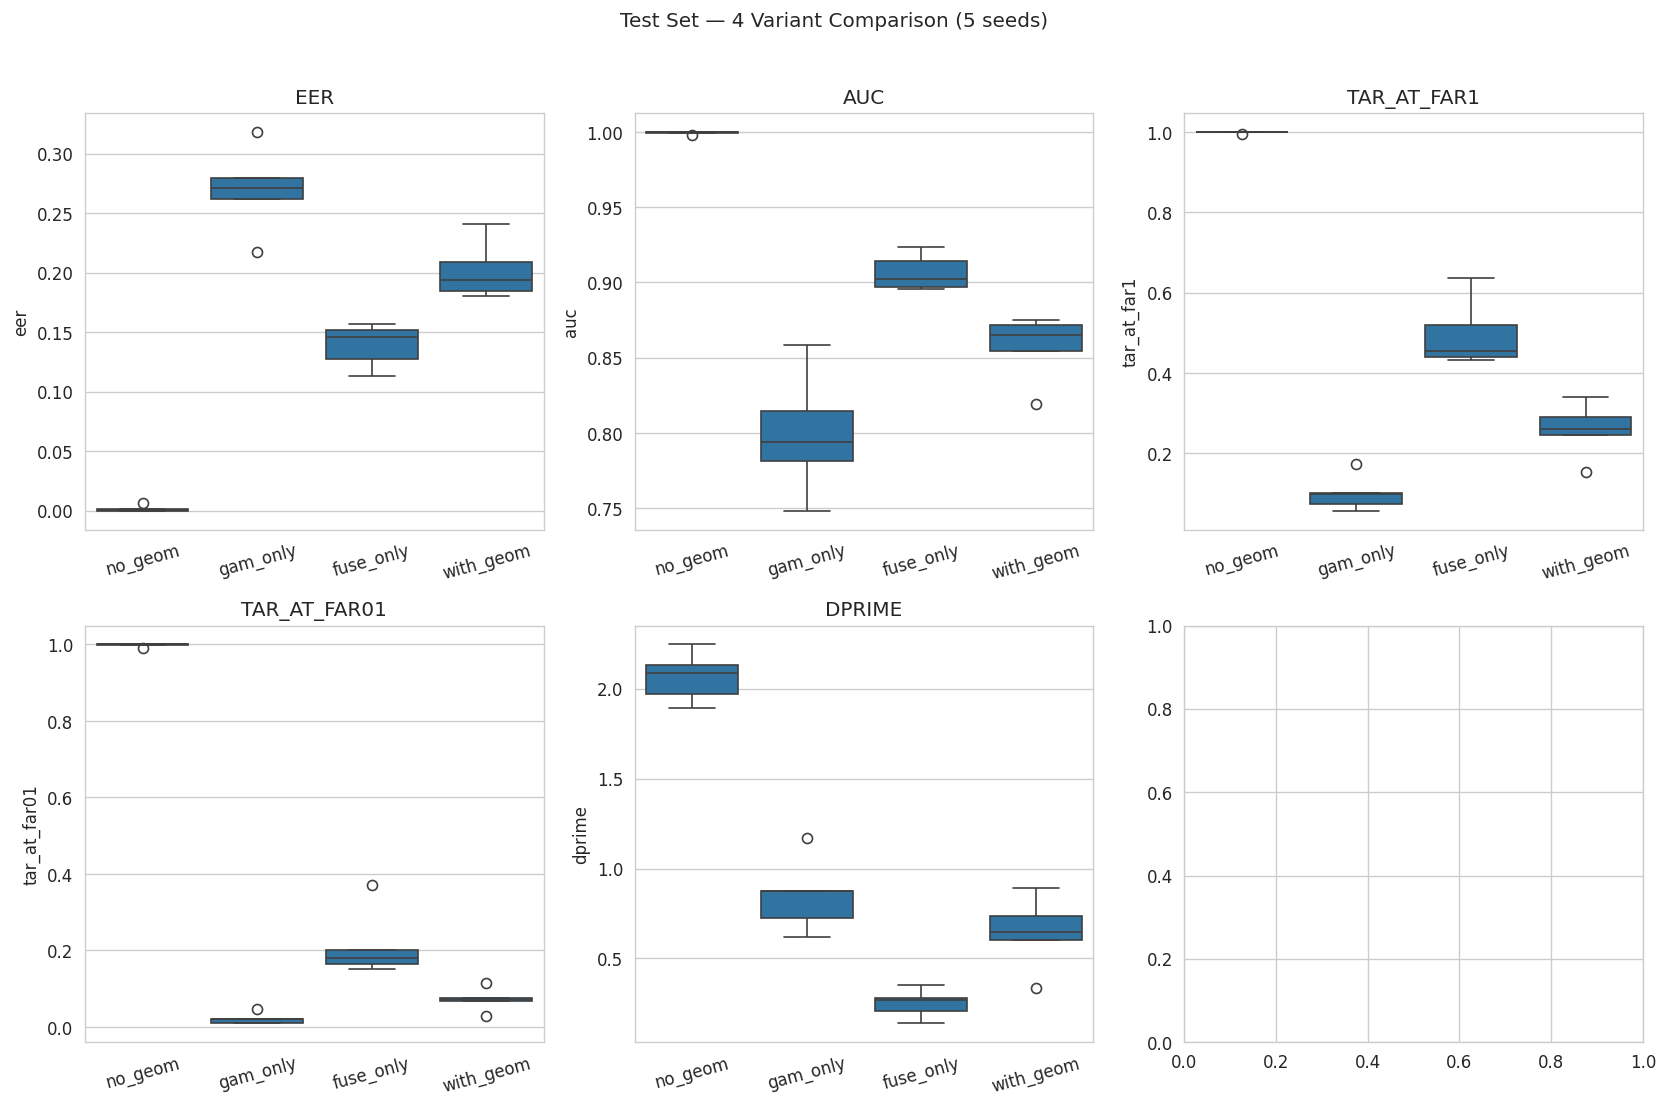

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
plot_metrics = [m for m in ["eer", "auc", "tar_at_far1", "tar_at_far01", "dprime", "rank1"] if m in df_test.columns]
for ax, metric in zip(axes.flat, plot_metrics):
    sns.boxplot(data=df_test, x="variant", y=metric, ax=ax, order=VARIANTS)
    ax.set_title(metric.upper())
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)
plt.suptitle("Test Set — 4 Variant Comparison (5 seeds)", y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "boxplots_test.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Boxplots — Holdout Set

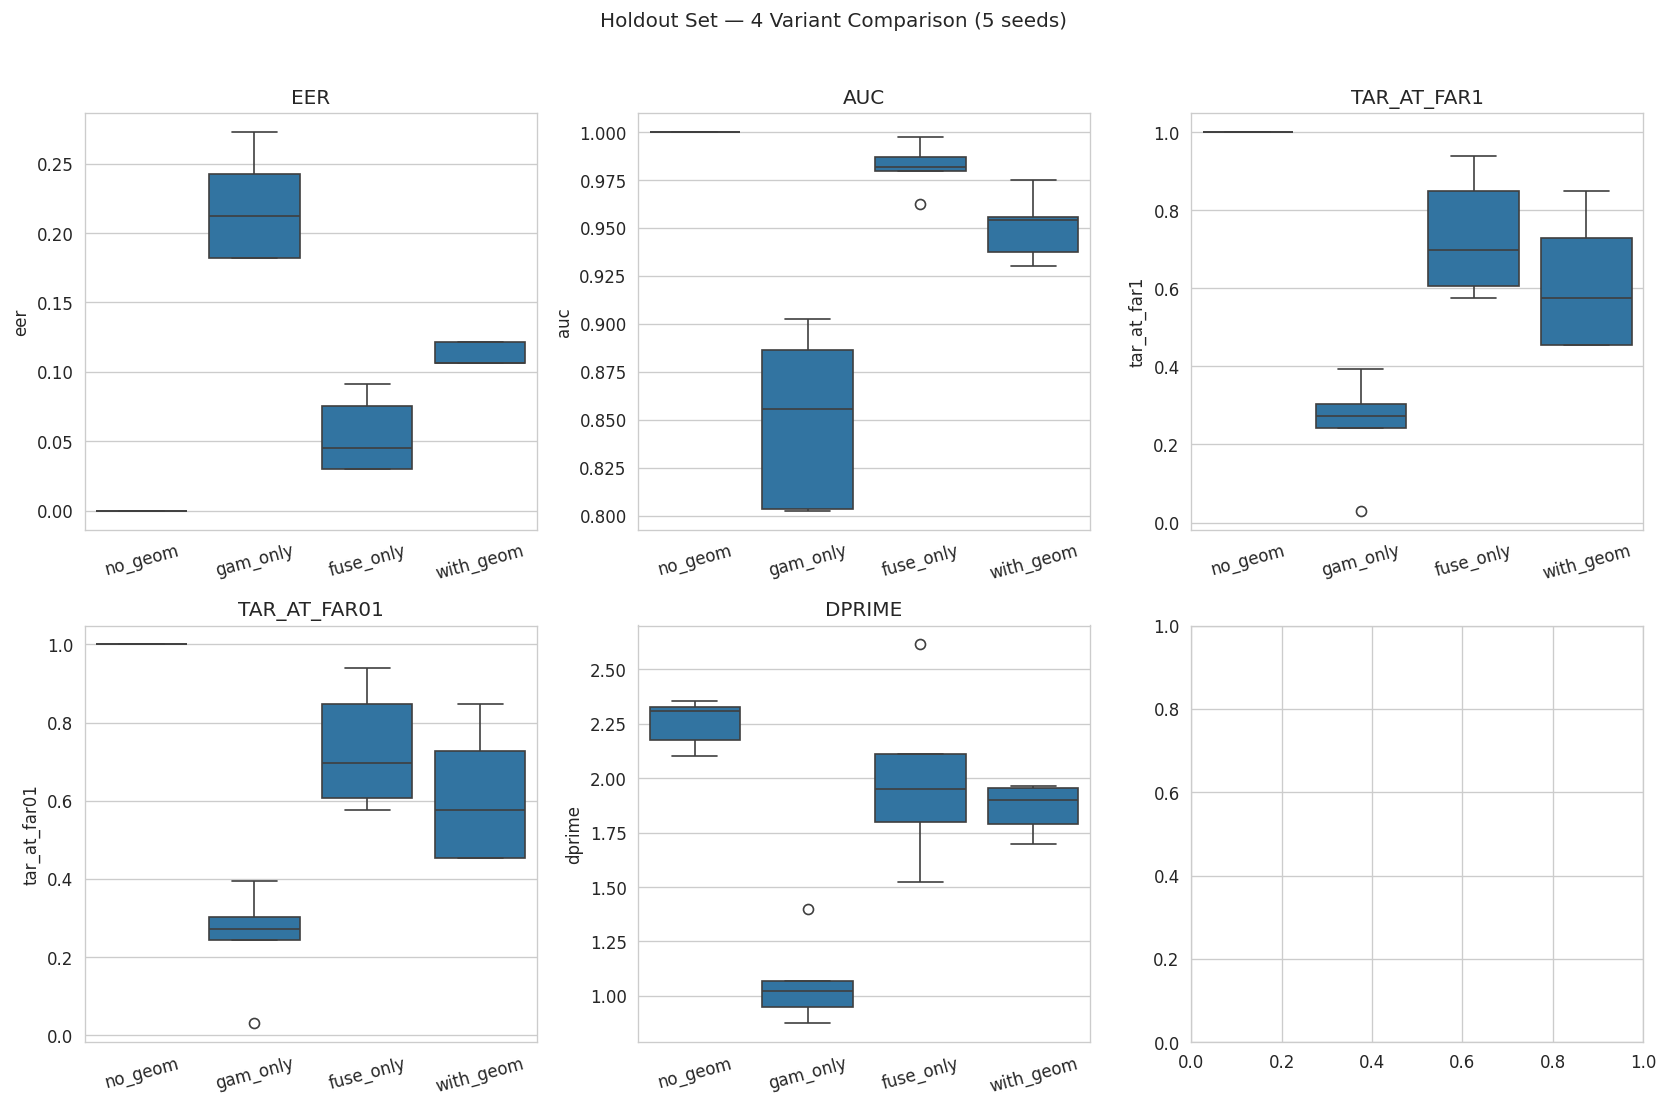

In [5]:
plot_metrics = [m for m in ["eer", "auc", "tar_at_far1", "tar_at_far01", "dprime", "rank1"] if m in df_holdout.columns]
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, metric in zip(axes.flat, plot_metrics):
    sns.boxplot(data=df_holdout, x="variant", y=metric, ax=ax, order=VARIANTS)
    ax.set_title(metric.upper())
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)
plt.suptitle("Holdout Set — 4 Variant Comparison (5 seeds)", y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "boxplots_holdout.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Statistical Tests — Uji Hipotesis Utama

Paired t-test antar variant per seed. Hipotesis utama: `with_geom` vs `no_geom`.

In [6]:
test_pairs = [
    ("with_geom", "no_geom"),    # Hipotesis utama: full GeoAtt vs PointNet++ murni
    ("with_geom", "gam_only"),   # Kontribusi fusion di atas GAM
    ("with_geom", "fuse_only"),  # Kontribusi GAM di atas fusion
    ("gam_only",  "no_geom"),    # Kontribusi GAM saja
    ("fuse_only", "no_geom"),    # Kontribusi fusion saja
]

def run_ttests(df, label):
    print(f"=== {label} — Paired T-Tests ===")
    for va, vb in test_pairs:
        print(f"\n[{va} vs {vb}]")
        for metric in [m for m in ["eer", "auc", "tar_at_far1", "rank1"] if m in df.columns]:
            t, p, d = paired_ttest(df, va, vb, metric)
            sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
            print(f"  {metric:12s}: t={t:7.3f}, p={p:.4f} [{sig}], Cohen's d={d:.3f}")

run_ttests(df_test,    "TEST SET")
print()
run_ttests(df_holdout, "HOLDOUT SET")


=== TEST SET — Paired T-Tests ===

[with_geom vs no_geom]
  eer         : t= 20.457, p=0.0000 [***], Cohen's d=9.148
  auc         : t=-14.704, p=0.0001 [***], Cohen's d=-6.576
  tar_at_far1 : t=-24.883, p=0.0000 [***], Cohen's d=-11.128

[with_geom vs gam_only]
  eer         : t= -2.664, p=0.0561 [ns], Cohen's d=-1.192
  auc         : t=  2.138, p=0.0993 [ns], Cohen's d=0.956
  tar_at_far1 : t=  3.333, p=0.0290 [*], Cohen's d=1.491

[with_geom vs fuse_only]
  eer         : t=  7.545, p=0.0017 [**], Cohen's d=3.374
  auc         : t= -6.243, p=0.0034 [**], Cohen's d=-2.792
  tar_at_far1 : t= -5.926, p=0.0041 [**], Cohen's d=-2.650

[gam_only vs no_geom]
  eer         : t= 15.602, p=0.0001 [***], Cohen's d=6.978
  auc         : t=-10.751, p=0.0004 [***], Cohen's d=-4.808
  tar_at_far1 : t=-42.998, p=0.0000 [***], Cohen's d=-19.229

[fuse_only vs no_geom]
  eer         : t= 18.322, p=0.0001 [***], Cohen's d=8.194
  auc         : t=-17.850, p=0.0001 [***], Cohen's d=-7.983
  tar_at_far1 :

## 7. CMC Curve — Identification 1:N

In [7]:
rank_cols = [c for c in ["rank1", "rank5", "rank10"] if c in df_test.columns]

if not rank_cols:
    print("SKIP: Rank columns tidak tersedia (evaluate.py tidak menghitung CMC/Rank-N)\n\nTIP: Jalankan ulang evaluasi dengan evaluate.py terbaru untuk menghasilkan rank1/rank5/rank10.")
else:
    ranks = [1, 5, 10][:len(rank_cols)]
    fig, ax = plt.subplots(figsize=(8, 6))
    for variant in VARIANTS:
        sub = df_test[df_test["variant"] == variant]
        if len(sub) == 0:
            continue
        means = [sub[c].mean() for c in rank_cols]
        stds  = [sub[c].std()  for c in rank_cols]
        ax.errorbar(ranks, means, yerr=stds, marker="o", capsize=4, linewidth=2, label=variant)

    ax.set_xlabel("Rank")
    ax.set_ylabel("Recognition Rate")
    ax.set_title("CMC Curve — Test Set (mean ± std across seeds)")
    ax.set_xticks(ranks)
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "cmc_curve.png", dpi=150, bbox_inches="tight")
    plt.show()


SKIP: Rank columns tidak tersedia (evaluate.py tidak menghitung CMC/Rank-N)

TIP: Jalankan ulang evaluasi dengan evaluate.py terbaru untuk menghasilkan rank1/rank5/rank10.


## 8. Pairwise Variant Metric Heatmap

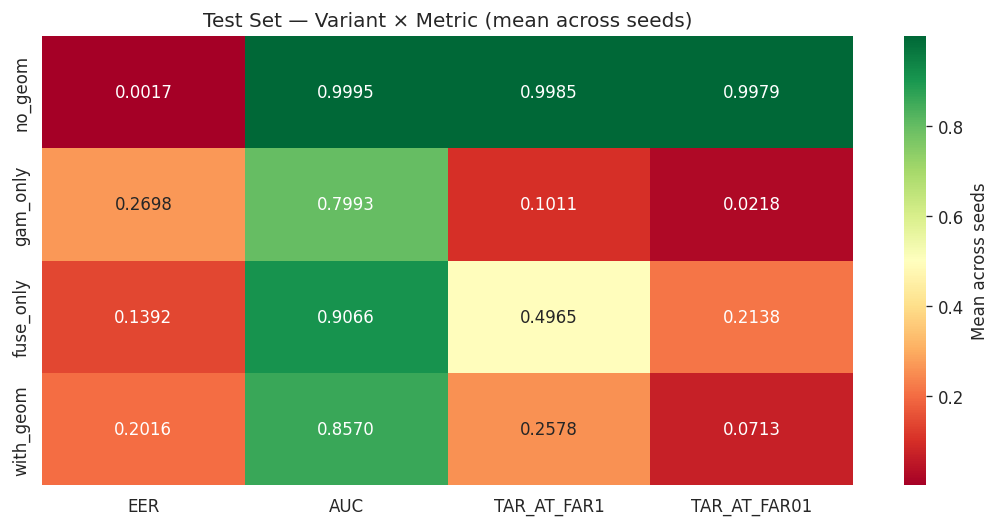

In [8]:
# Heatmap rangkuman: baris = variant, kolom = metric. Mean across seeds.
heatmap_metrics = [m for m in ["eer", "auc", "tar_at_far1", "tar_at_far01", "rank1", "rank5"] if m in df_test.columns]
mat = np.array([
    [df_test[df_test["variant"] == v][m].mean() for m in heatmap_metrics]
    for v in VARIANTS
])
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.heatmap(
    mat, annot=True, fmt=".4f", cmap="RdYlGn",
    xticklabels=[m.upper() for m in heatmap_metrics],
    yticklabels=VARIANTS, ax=ax, cbar_kws={"label": "Mean across seeds"},
)
ax.set_title("Test Set — Variant × Metric (mean across seeds)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "variant_metric_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Similarity Distribution — Genuine vs Impostor

Load file `*_scores.npz` yang ditulis oleh `evaluate.py --save_scores`. Cell ini di-skip otomatis kalau `.npz` belum ada.

Visual ini penting untuk defense: kalau GeoAtt memang signifikan, distribusi genuine vs impostor seharusnya lebih ter-separasi di `with_geom` daripada di `no_geom`.

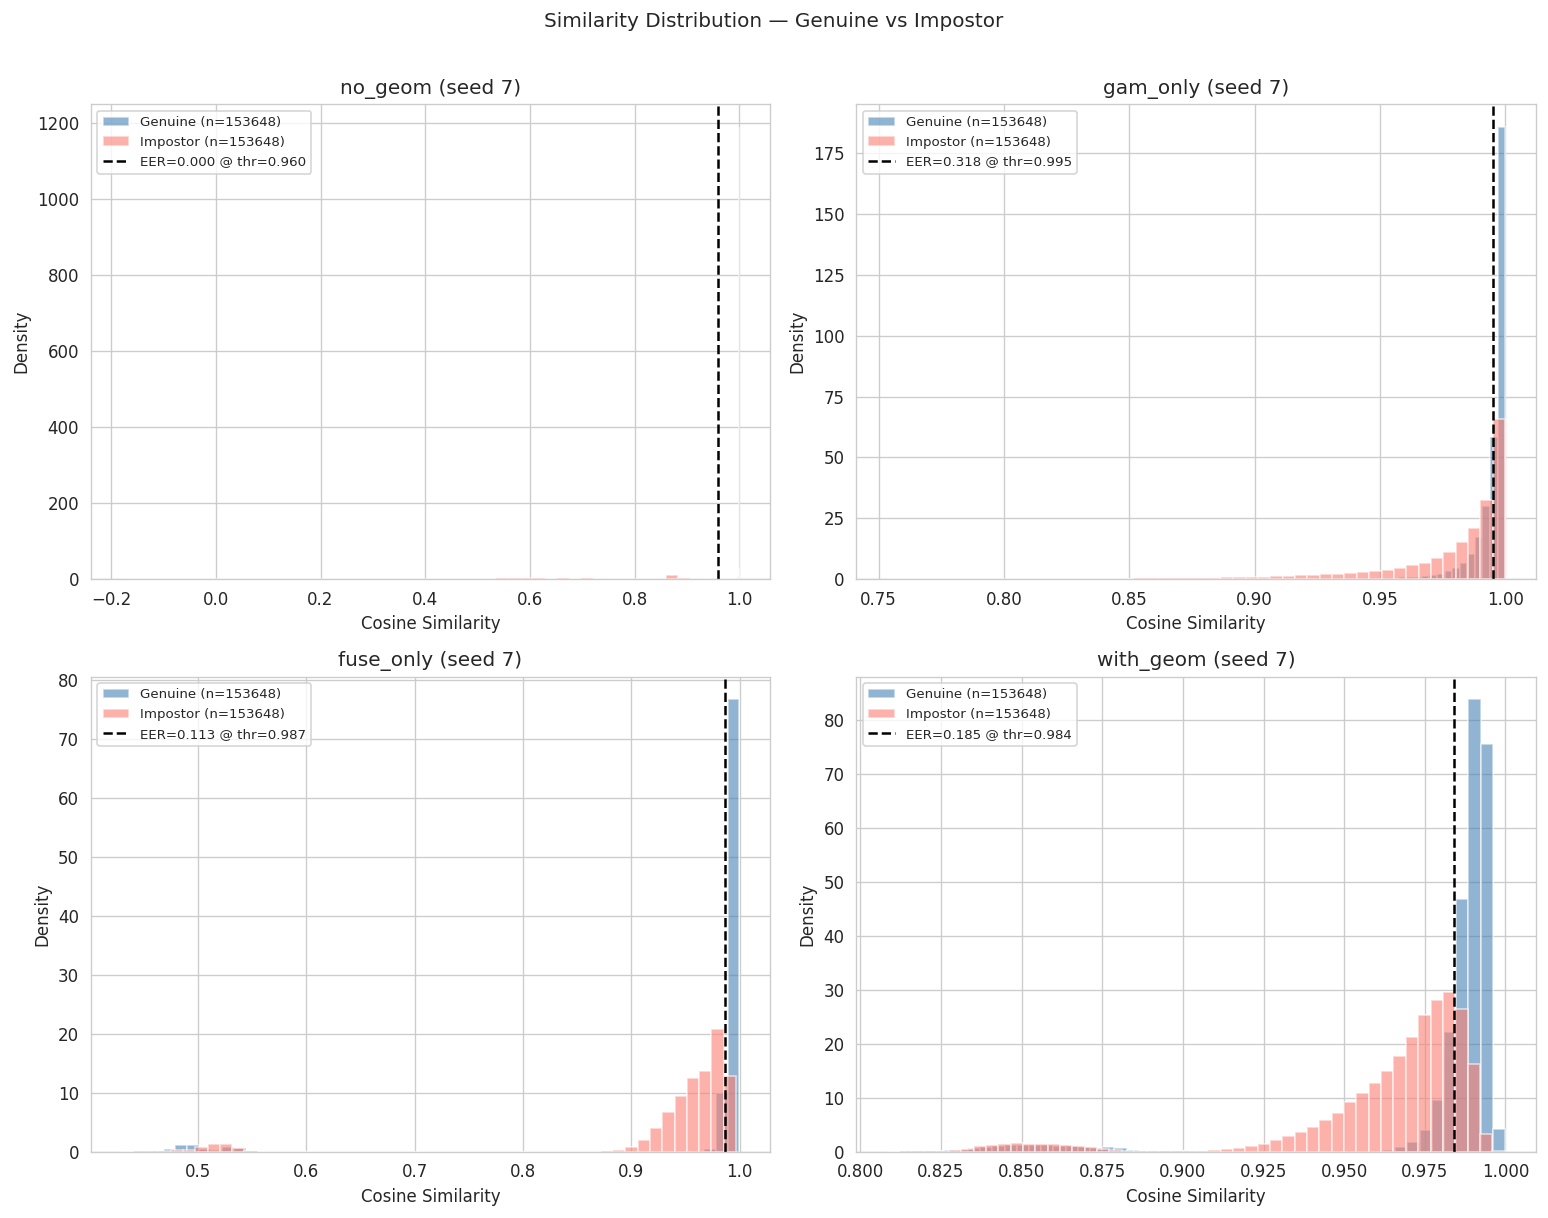

In [9]:
from sklearn.metrics import roc_curve

def compute_eer_threshold(labels, scores):
    fpr, tpr, thr = roc_curve(labels, scores)
    fnr = 1 - tpr
    idx = np.nanargmin(np.abs(fnr - fpr))
    return thr[idx], (fpr[idx] + fnr[idx]) / 2.0

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flat
rep_seed = SEEDS[0] if SEEDS else 42

for ax, variant in zip(axes, VARIANTS):
    npz_path = EVAL_DIR / variant / f"seed_{rep_seed}" / f"{variant}_scores.npz"
    if not npz_path.exists():
        ax.set_title(f"{variant} — .npz missing")
        ax.set_axis_off()
        continue
    data    = np.load(npz_path)
    labels  = data["labels"]
    scores  = data["scores"]
    genuine = scores[labels == 1]
    impost  = scores[labels == 0]
    eer_thr, eer = compute_eer_threshold(labels, scores)

    ax.hist(genuine, bins=50, alpha=0.6, label=f"Genuine (n={len(genuine)})", color="steelblue", density=True)
    ax.hist(impost,  bins=50, alpha=0.6, label=f"Impostor (n={len(impost)})", color="salmon",   density=True)
    ax.axvline(eer_thr, color="black", linestyle="--", label=f"EER={eer:.3f} @ thr={eer_thr:.3f}")
    ax.set_title(f"{variant} (seed {rep_seed})")
    ax.set_xlabel("Cosine Similarity")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.suptitle("Similarity Distribution — Genuine vs Impostor", y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "similarity_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


## 10. Export Tables

In [10]:
agg_test = aggregate_by_variant(df_test)
agg_test.to_csv(OUTPUT_DIR / "aggregate_test.csv")
print("Saved:", OUTPUT_DIR / "aggregate_test.csv")

agg_holdout = aggregate_by_variant(df_holdout)
agg_holdout.to_csv(OUTPUT_DIR / "aggregate_holdout.csv")
print("Saved:", OUTPUT_DIR / "aggregate_holdout.csv")

latex_test = export_latex_table(
    df_test,
    metrics=[m for m in ["eer", "auc", "tar_at_far1", "rank1"] if m in df_test.columns],
    save_path=OUTPUT_DIR / "table_test.tex",
    caption="Fair Ablation Results on Test Set (mean $\\pm$ std, 5 seeds)",
)
print("Saved:", OUTPUT_DIR / "table_test.tex")

latex_holdout = export_latex_table(
    df_holdout,
    metrics=[m for m in ["eer", "auc", "tar_at_far1", "rank1"] if m in df_holdout.columns],
    save_path=OUTPUT_DIR / "table_holdout.tex",
    caption="Fair Ablation Results on Holdout Set (mean $\\pm$ std, 5 seeds)",
)
print("Saved:", OUTPUT_DIR / "table_holdout.tex")


Saved: /content/drive/MyDrive/3DCNN/analysis/aggregate_test.csv
Saved: /content/drive/MyDrive/3DCNN/analysis/aggregate_holdout.csv
Saved: /content/drive/MyDrive/3DCNN/analysis/table_test.tex
Saved: /content/drive/MyDrive/3DCNN/analysis/table_holdout.tex


## 11. Completion

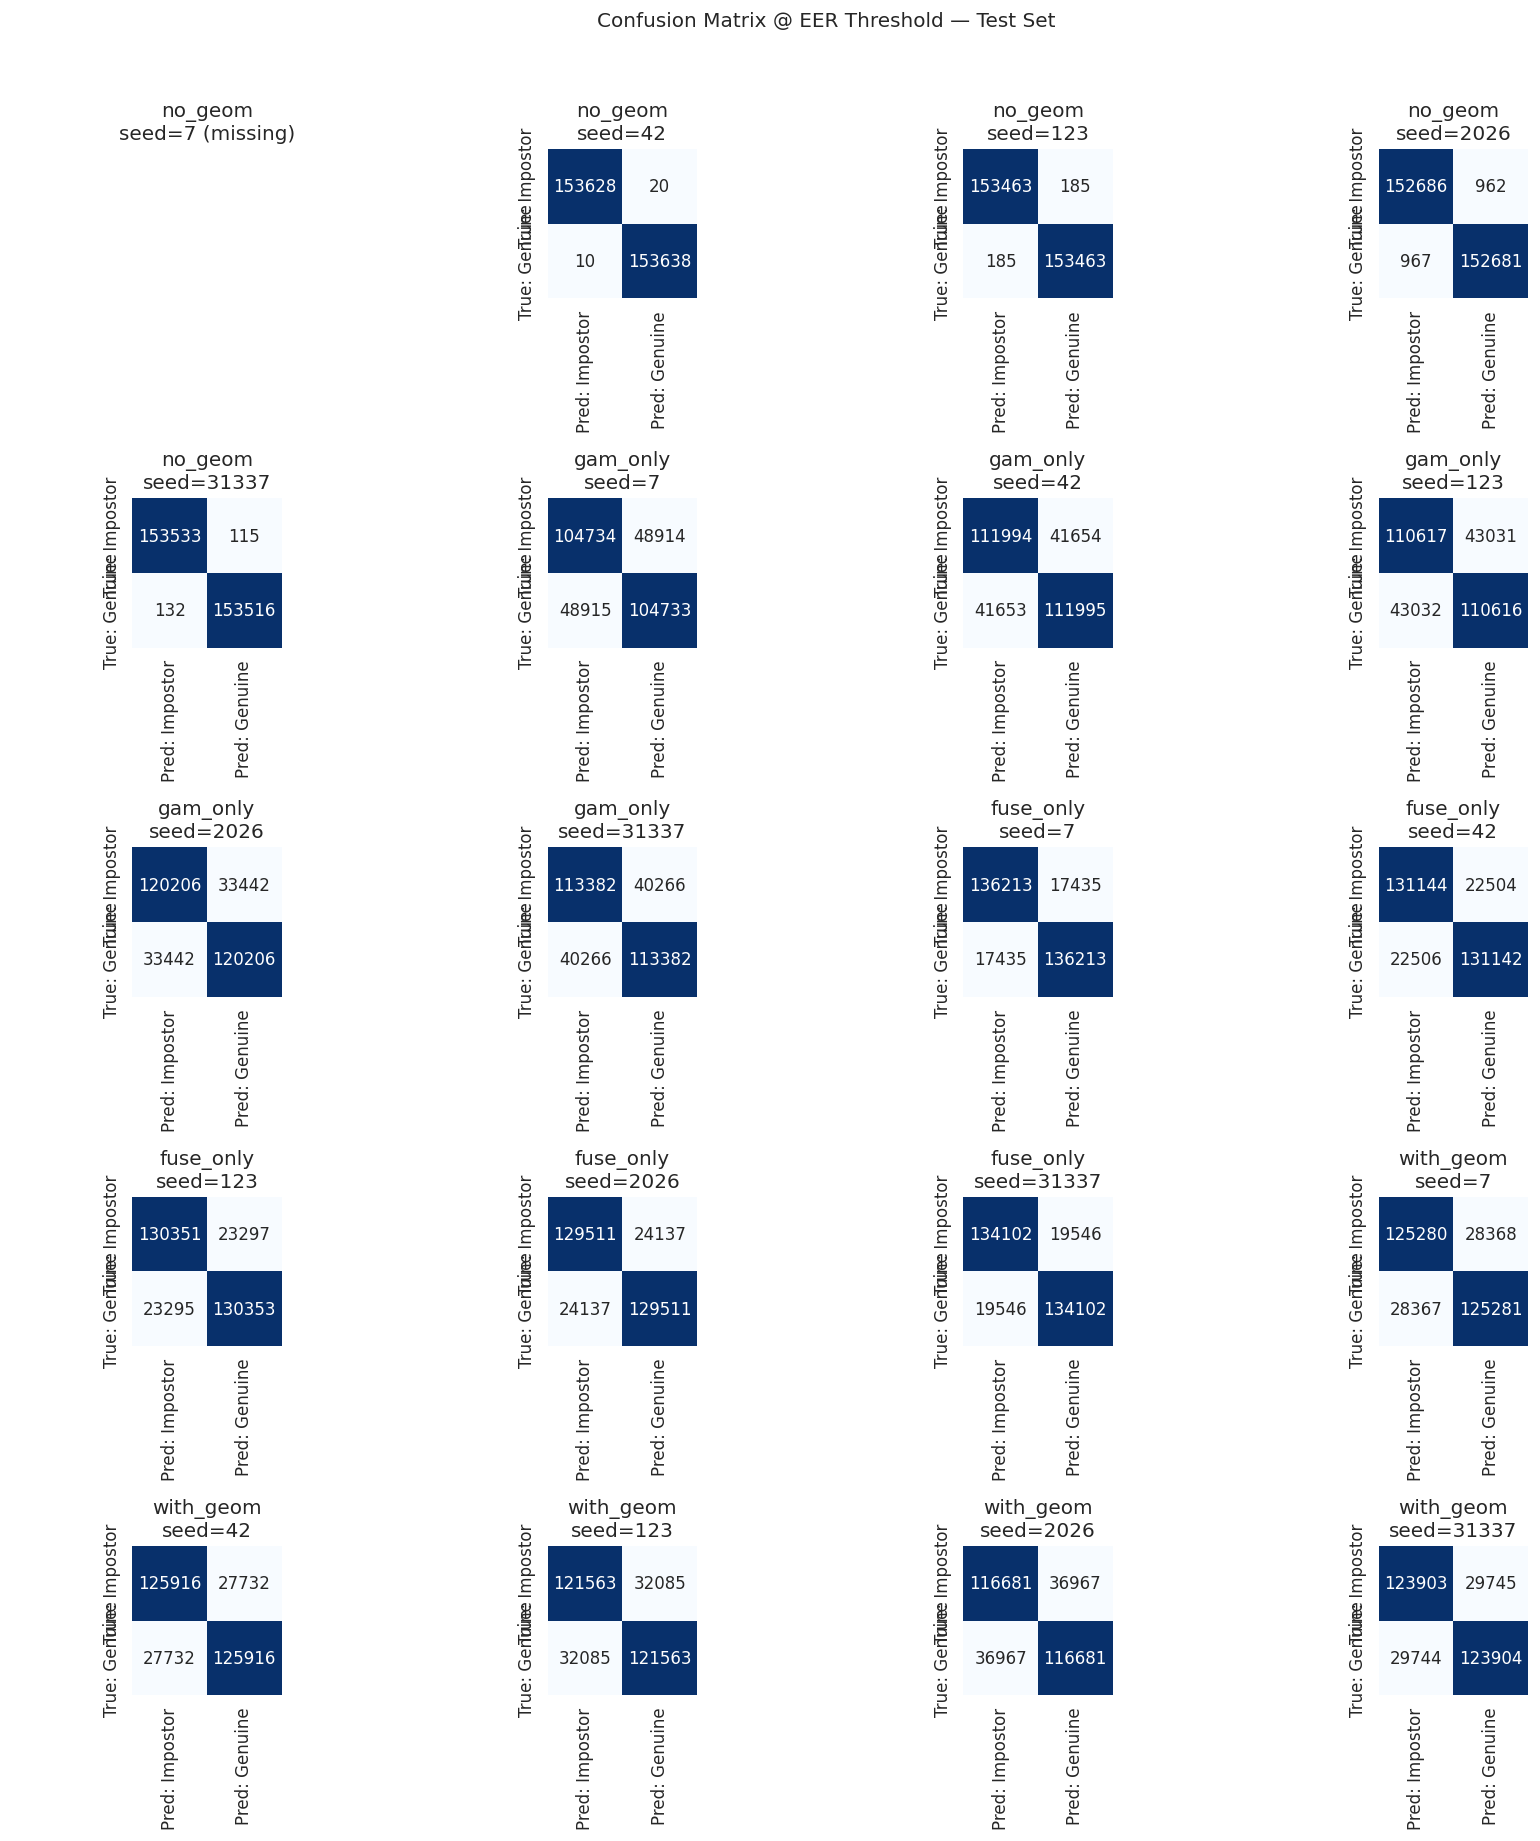


=== Confusion Matrix Summary (Test Set) ===

  variant  seed     TP     TN    FP    FN Precision Recall     F1 Threshold
  no_geom    42 153638 153628    20    10    0.9999 0.9999 0.9999    0.9628
  no_geom   123 153463 153463   185   185    0.9988 0.9988 0.9988    0.9305
  no_geom  2026 152681 152686   962   967    0.9937 0.9937 0.9937    0.9074
  no_geom 31337 153516 153533   115   132    0.9993 0.9991 0.9992    0.9290
 gam_only     7 104733 104734 48914 48915    0.6816 0.6816 0.6816    0.9952
 gam_only    42 111995 111994 41654 41653    0.7289 0.7289 0.7289    0.9758
 gam_only   123 110616 110617 43031 43032    0.7199 0.7199 0.7199    0.9959
 gam_only  2026 120206 120206 33442 33442    0.7823 0.7823 0.7823    0.9540
 gam_only 31337 113382 113382 40266 40266    0.7379 0.7379 0.7379    0.9928
fuse_only     7 136213 136213 17435 17435    0.8865 0.8865 0.8865    0.9865
fuse_only    42 131142 131144 22504 22506    0.8535 0.8535 0.8535    0.9902
fuse_only   123 130353 130351 23297 23295 

In [11]:
# ============================================================
# Confusion Matrix per Variant/Seed (EER Threshold)
# ============================================================

def plot_confusion_matrix_heatmap(cm_dict, title, ax):
    tp, tn, fp, fn = cm_dict["tp"], cm_dict["tn"], cm_dict["fp"], cm_dict["fn"]
    cm = np.array([[tn, fp], [fn, tp]])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Pred: Impostor", "Pred: Genuine"],
                yticklabels=["True: Impostor", "True: Genuine"],
                cbar=False, square=True)
    ax.set_title(title)

# Cek apakah flattened confusion matrix tersedia (evaluate.py terbaru)
has_flat_cm = all(c in df_test.columns for c in ["tp", "tn", "fp", "fn"])
has_nested_cm = "confusion_matrix" in df_test.columns

if not has_flat_cm and not has_nested_cm:
    print("SKIP: Confusion matrix belum tersedia.\n")
    print("→ Jalankan ulang evaluasi dengan evaluate.py yang sudah di-update,")
    print("   lalu re-run notebook ini.")
else:
    n_total = len(VARIANTS) * len(SEEDS)
    ncols = min(4, n_total)
    nrows = (n_total + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.5 * ncols, 3 * nrows))
    axes = axes.flat if n_total > 1 else [axes]

    for ax, (variant, seed) in zip(axes, [(v, s) for v in VARIANTS for s in SEEDS]):
        sub = df_test[(df_test["variant"] == variant) & (df_test["seed"] == seed)]
        if len(sub) == 0:
            ax.set_title(f"{variant}\nseed={seed} (missing)")
            ax.set_axis_off()
            continue

        # Prioritas: flattened columns (evaluate.py terbaru)
        if has_flat_cm:
            row = sub.iloc[0]
            if pd.isna(row.get("tp")):
                ax.set_title(f"{variant}\nseed={seed} (missing)")
                ax.set_axis_off()
                continue
            cm_dict = {
                "tp": int(row["tp"]), "tn": int(row["tn"]),
                "fp": int(row["fp"]), "fn": int(row["fn"]),
            }
        else:
            if pd.isna(sub["confusion_matrix"].values[0]):
                ax.set_title(f"{variant}\nseed={seed} (missing)")
                ax.set_axis_off()
                continue
            cm_dict = sub["confusion_matrix"].values[0]

        plot_confusion_matrix_heatmap(cm_dict, f"{variant}\nseed={seed}", ax)

    for ax in axes[n_total:]:
        ax.set_axis_off()

    plt.suptitle("Confusion Matrix @ EER Threshold — Test Set", y=1.02)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "confusion_matrices_test.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("\n=== Confusion Matrix Summary (Test Set) ===\n")
    rows = []
    for variant in VARIANTS:
        for seed in SEEDS:
            sub = df_test[(df_test["variant"] == variant) & (df_test["seed"] == seed)]
            if len(sub) == 0:
                continue
            if has_flat_cm and not pd.isna(sub.iloc[0].get("tp")):
                row = sub.iloc[0]
                rows.append({
                    "variant": variant, "seed": seed,
                    "TP": int(row["tp"]), "TN": int(row["tn"]),
                    "FP": int(row["fp"]), "FN": int(row["fn"]),
                    "Precision": f"{row['precision']:.4f}",
                    "Recall": f"{row['recall']:.4f}",
                    "F1": f"{row['f1']:.4f}",
                    "Threshold": f"{row['cm_threshold']:.4f}",
                })
            elif has_nested_cm and not pd.isna(sub["confusion_matrix"].values[0]):
                cm = sub["confusion_matrix"].values[0]
                rows.append({
                    "variant": variant, "seed": seed,
                    "TP": cm["tp"], "TN": cm["tn"], "FP": cm["fp"], "FN": cm["fn"],
                    "Precision": f"{cm['precision']:.4f}",
                    "Recall": f"{cm['recall']:.4f}",
                    "F1": f"{cm['f1']:.4f}",
                    "Threshold": f"{cm['threshold']:.4f}",
                })
    if rows:
        df_cm = pd.DataFrame(rows)
        print(df_cm.to_string(index=False))
        df_cm.to_csv(OUTPUT_DIR / "confusion_matrix_summary.csv", index=False)
        print(f"\nSaved: {OUTPUT_DIR / 'confusion_matrix_summary.csv'}")
    else:
        print("No confusion matrix data available.")


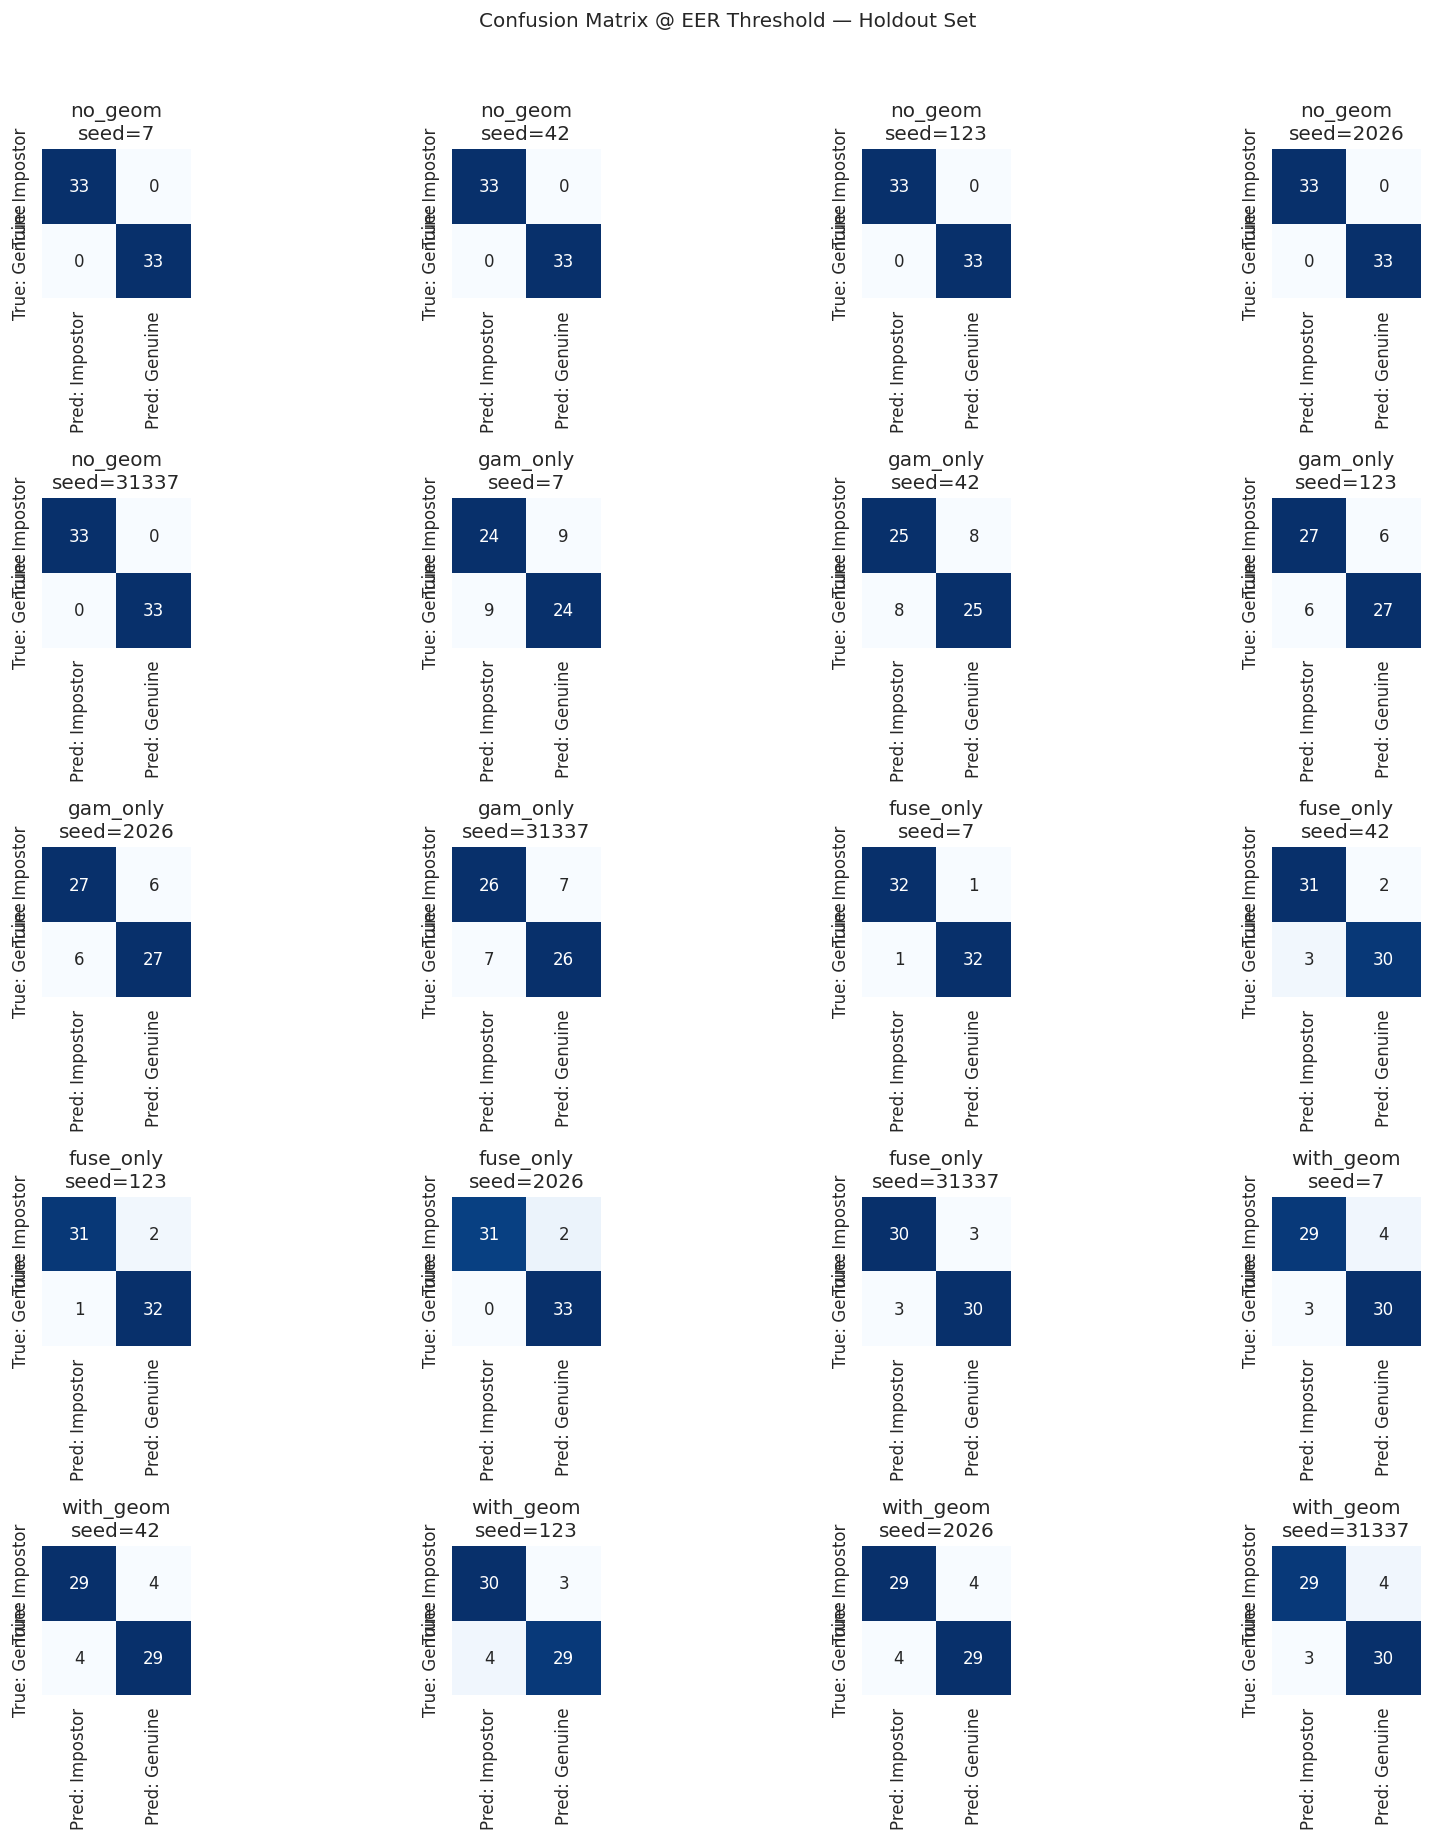


=== Confusion Matrix Summary (Holdout Set) ===

  variant  seed  TP  TN  FP  FN Precision Recall     F1 Threshold
  no_geom     7  33  33   0   0    1.0000 1.0000 1.0000    0.9911
  no_geom    42  33  33   0   0    1.0000 1.0000 1.0000    0.9999
  no_geom   123  33  33   0   0    1.0000 1.0000 1.0000    0.9977
  no_geom  2026  33  33   0   0    1.0000 1.0000 1.0000    0.9983
  no_geom 31337  33  33   0   0    1.0000 1.0000 1.0000    0.9999
 gam_only     7  24  24   9   9    0.7273 0.7273 0.7273    0.9961
 gam_only    42  25  25   8   8    0.7576 0.7576 0.7576    0.9780
 gam_only   123  27  27   6   6    0.8182 0.8182 0.8182    0.9979
 gam_only  2026  27  27   6   6    0.8182 0.8182 0.8182    0.9586
 gam_only 31337  26  26   7   7    0.7879 0.7879 0.7879    0.9959
fuse_only     7  32  32   1   1    0.9697 0.9697 0.9697    0.9915
fuse_only    42  30  31   2   3    0.9375 0.9091 0.9231    0.9933
fuse_only   123  32  31   2   1    0.9412 0.9697 0.9552    0.9907
fuse_only  2026  33  31   2

In [12]:
# ============================================================
# Confusion Matrix @ EER Threshold — HOLDOUT SET
# ============================================================

has_flat_cm_ho = all(c in df_holdout.columns for c in ["tp", "tn", "fp", "fn"])
has_nested_cm_ho = "confusion_matrix" in df_holdout.columns

if not has_flat_cm_ho and not has_nested_cm_ho:
    print("SKIP: Confusion matrix belum tersedia untuk holdout.\n")
    print("→ Jalankan ulang holdout evaluasi dengan evaluate.py --holdout yang sudah di-update,")
    print("   lalu re-run notebook ini.")
else:
    n_total = len(VARIANTS) * len(SEEDS)
    ncols = min(4, n_total)
    nrows = (n_total + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.5 * ncols, 3 * nrows))
    axes = axes.flat if n_total > 1 else [axes]

    for ax, (variant, seed) in zip(axes, [(v, s) for v in VARIANTS for s in SEEDS]):
        sub = df_holdout[(df_holdout["variant"] == variant) & (df_holdout["seed"] == seed)]
        if len(sub) == 0:
            ax.set_title(f"{variant}\nseed={seed} (missing)")
            ax.set_axis_off()
            continue

        if has_flat_cm_ho:
            row = sub.iloc[0]
            if pd.isna(row.get("tp")):
                ax.set_title(f"{variant}\nseed={seed} (missing)")
                ax.set_axis_off()
                continue
            cm_dict = {
                "tp": int(row["tp"]), "tn": int(row["tn"]),
                "fp": int(row["fp"]), "fn": int(row["fn"]),
            }
        else:
            if pd.isna(sub["confusion_matrix"].values[0]):
                ax.set_title(f"{variant}\nseed={seed} (missing)")
                ax.set_axis_off()
                continue
            cm_dict = sub["confusion_matrix"].values[0]

        plot_confusion_matrix_heatmap(cm_dict, f"{variant}\nseed={seed}", ax)

    for ax in axes[n_total:]:
        ax.set_axis_off()

    plt.suptitle("Confusion Matrix @ EER Threshold — Holdout Set", y=1.02)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "confusion_matrices_holdout.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("\n=== Confusion Matrix Summary (Holdout Set) ===\n")
    rows = []
    for variant in VARIANTS:
        for seed in SEEDS:
            sub = df_holdout[(df_holdout["variant"] == variant) & (df_holdout["seed"] == seed)]
            if len(sub) == 0:
                continue
            if has_flat_cm_ho and not pd.isna(sub.iloc[0].get("tp")):
                row = sub.iloc[0]
                rows.append({
                    "variant": variant, "seed": seed,
                    "TP": int(row["tp"]), "TN": int(row["tn"]),
                    "FP": int(row["fp"]), "FN": int(row["fn"]),
                    "Precision": f"{row['precision']:.4f}",
                    "Recall": f"{row['recall']:.4f}",
                    "F1": f"{row['f1']:.4f}",
                    "Threshold": f"{row['cm_threshold']:.4f}",
                })
            elif has_nested_cm_ho and not pd.isna(sub["confusion_matrix"].values[0]):
                cm = sub["confusion_matrix"].values[0]
                rows.append({
                    "variant": variant, "seed": seed,
                    "TP": cm["tp"], "TN": cm["tn"], "FP": cm["fp"], "FN": cm["fn"],
                    "Precision": f"{cm['precision']:.4f}",
                    "Recall": f"{cm['recall']:.4f}",
                    "F1": f"{cm['f1']:.4f}",
                    "Threshold": f"{cm['threshold']:.4f}",
                })
    if rows:
        df_cm_ho = pd.DataFrame(rows)
        print(df_cm_ho.to_string(index=False))
        df_cm_ho.to_csv(OUTPUT_DIR / "confusion_matrix_summary_holdout.csv", index=False)
        print(f"\nSaved: {OUTPUT_DIR / 'confusion_matrix_summary_holdout.csv'}")
    else:
        print("No confusion matrix data available for holdout.")


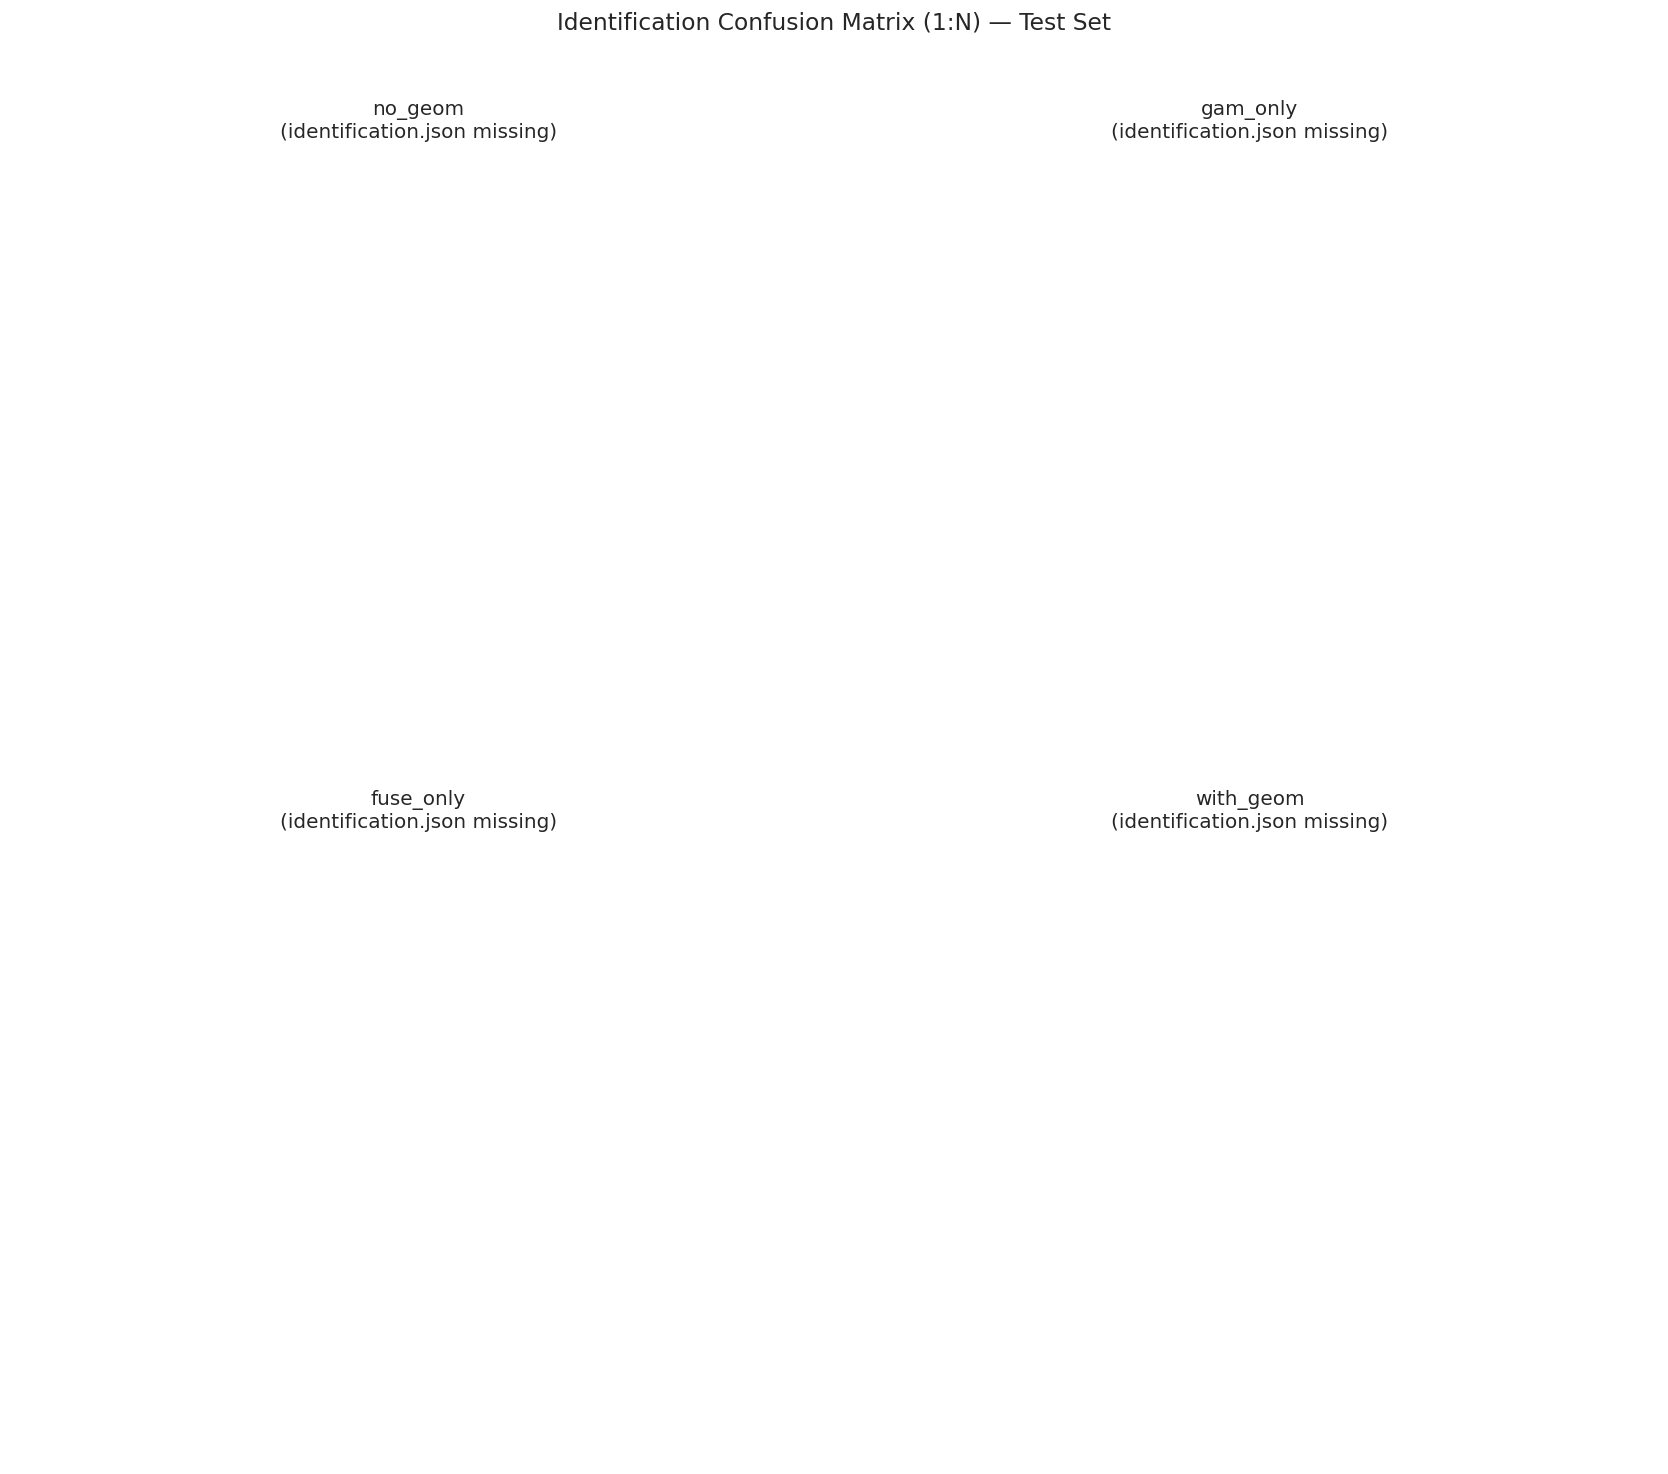


=== Per-Subject Identification Accuracy (Test Set) ===

Empty DataFrame
Columns: []
Index: []

Saved: /content/drive/MyDrive/3DCNN/analysis/identification_accuracy_per_subject_test.csv


In [13]:
# ============================================================
# Identification Confusion Matrix — Test Set
# ============================================================

from sklearn.metrics import confusion_matrix

def load_identification_results(eval_dir, variant, seed):
    path = eval_dir / variant / f"seed_{seed}" / f"{variant}_identification.json"
    if not path.exists():
        return None
    with open(path) as f:
        return json.load(f)

# Pilih satu seed representatif untuk visualisasi
rep_seed = SEEDS[0]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flat

for ax, variant in zip(axes, VARIANTS):
    id_data = load_identification_results(EVAL_DIR, variant, rep_seed)
    if id_data is None or not id_data.get("probe_results"):
        ax.set_title(f"{variant}\n(identification.json missing)")
        ax.set_axis_off()
        continue

    labels = id_data["gallery_labels"]
    y_true = [r["true_label"] for r in id_data["probe_results"]]
    y_pred = [r["pred_label"] for r in id_data["probe_results"]]

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    acc = (np.array(y_true) == np.array(y_pred)).mean()

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=labels, yticklabels=labels,
                cbar=False, square=True)
    ax.set_xlabel("Predicted Identity")
    ax.set_ylabel("True Identity")
    ax.set_title(f"{variant}\nRank-1 Acc = {acc:.2%} (seed {rep_seed})")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

plt.suptitle("Identification Confusion Matrix (1:N) — Test Set", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "identification_confusion_matrix_test.png", dpi=150, bbox_inches="tight")
plt.show()

# Tabel per-subject accuracy
print("\n=== Per-Subject Identification Accuracy (Test Set) ===\n")
rows = []
for variant in VARIANTS:
    for seed in SEEDS:
        id_data = load_identification_results(EVAL_DIR, variant, seed)
        if id_data is None or not id_data.get("probe_results"):
            continue
        y_true = [r["true_label"] for r in id_data["probe_results"]]
        y_pred = [r["pred_label"] for r in id_data["probe_results"]]
        labels = id_data["gallery_labels"]
        for lbl in labels:
            mask = np.array(y_true) == lbl
            correct = (np.array(y_pred)[mask] == lbl).sum()
            total = mask.sum()
            rows.append({
                "variant": variant, "seed": seed,
                "subject": lbl,
                "correct": correct, "total": total,
                "accuracy": f"{correct/total:.2%}" if total > 0 else "N/A",
            })
df_id_acc = pd.DataFrame(rows)
print(df_id_acc.to_string(index=False))
df_id_acc.to_csv(OUTPUT_DIR / "identification_accuracy_per_subject_test.csv", index=False)
print(f"\nSaved: {OUTPUT_DIR / 'identification_accuracy_per_subject_test.csv'}")


In [14]:
print("All analysis outputs saved to:")
for f in sorted(OUTPUT_DIR.iterdir()):
    print(f"  {f.name}")


All analysis outputs saved to:
  aggregate_holdout.csv
  aggregate_test.csv
  boxplots_holdout.png
  boxplots_test.png
  confusion_matrices_holdout.png
  confusion_matrices_test.png
  confusion_matrix_summary.csv
  confusion_matrix_summary_holdout.csv
  identification_accuracy_per_subject_test.csv
  identification_confusion_matrix_test.png
  similarity_distribution.png
  table_holdout.tex
  table_test.tex
  variant_metric_heatmap.png


In [15]:
# ============================================================
# SHUTDOWN — Save Compute Units
# ============================================================

import sys

try:
    # Check if a previous cell failed. If it did, this logs it.
    print("Notebook execution reached the final cell.")
except Exception as e:
    print(f"An unexpected error occurred in the final cell: {e}", file=sys.stderr)
finally:
    print("Shutting down VM immediately to save compute units...")

    # This command kills the server in the background
    from google.colab import runtime
    runtime.unassign()


Notebook execution reached the final cell.
Shutting down VM immediately to save compute units...
